# Taller: Agentes Inteligentes 🤖🧠
## Racionalidad, Agentes Reflexivos, Agentes con Estado y Sistemas Multiagente
**Curso de Inteligencia Artificial – 2026**

---

### 1. Información de los Integrantes

| # | Nombre Completo |
|---|---|
| 1 | **Santiago Parra Acuña** |
| 2 | **Sergio Alberto Morales Piraján** |
| 3 | **Ángel De Jesús Robles Araque** |

---


## 2. Punto 1 – Racionalidad del Agente Aspiradora

### 2.1 Análisis de Racionalidad (Escenario Russell & Norvig – Figuras 2.1, 2.2 y 2.3)

![Agentes y Entornos – Figura 2.1](images/figure_2_1_agent_environment.png)
*Figura 2.1: Los agentes interactúan con los entornos a través de sensores (percepciones) y actuadores (acciones).*

![Mundo Aspiradora – Figuras 2.2 y 2.3](images/figure_2_2_and_2_3_vacuum_world.png)
*Figuras 2.2 y 2.3: Mundo de la aspiradora de dos ubicaciones (A y B) y tabulación de la función de agente.*

---

#### Marco Conceptual PEAS (Performance, Environment, Actuators, Sensors)

| Componente | Descripción |
|---|---|
| **Medida de Desempeño ($P$)** | $+1$ punto por cada casilla limpia en cada unidad de tiempo $t$. |
| **Ambiente ($E$)** | Dos casillas ($A$ y $B$). Las casillas no se ensucian solas una vez limpiadas. |
| **Actuadores ($A$)** | $\{\text{Izquierda}, \text{Derecha}, \text{Aspirar}, \text{NoOp}\}$ |
| **Sensores ($S$)** | Percibe la casilla actual y su estado: $\text{percepción} = [\text{ubicación}, \text{estado}]$ |

---

#### Definición Formal de Agente Racional
Un agente es **racional** si, para cada posible secuencia de percepciones, selecciona la acción que **maximiza el valor esperado** de la medida de desempeño $P$, dado el conocimiento previo incorporado y la información provista por las percepciones recibidas hasta ese momento (Russell & Norvig, 2020).

---

#### Demostración Formal de Racionalidad

Consideremos la función de agente descrita en la Figura 2.3:

$$\begin{aligned}
[A, \text{Clean}] &\to \text{Right} \\
[A, \text{Dirty}] &\to \text{Suck} \\
[B, \text{Clean}] &\to \text{Left} \\
[B, \text{Dirty}] &\to \text{Suck}
\end{aligned}$$

**Análisis caso por caso de la función de decisión:**

1. **Estado $[A, \text{Dirty}]$:** Ejecutar $\text{Suck}$ transforma la casilla a limpia, otorgando $+1$ en el siguiente paso. Cualquier otra acción (como trasladarse a $B$) deja $A$ sucia, obteniendo $0$ puntos inmediatos de limpieza en $A$. Por lo tanto, $\text{Suck}$ es la acción que maximiza estrictamente la utilidad esperada.
2. **Estado $[A, \text{Clean}]$:** Ya que la casilla $A$ está limpia, permanecer en $A$ ($\text{NoOp}$) genera $0$ ganancia marginal. Trasladarse a $B$ mediante $\text{Right}$ permite acceder a una casilla potencialmente sucia. Si $B$ estaba sucia, podrá aspirarse en el siguiente paso (beneficio futuro $+1$). La acción con mayor utilidad esperada es $\text{Right}$.
3. **Estados $[B, \text{Dirty}]$ y $[B, \text{Clean}]$:** Por simetría espacial, aplica idéntica deducción lógica.

$$\mathbb{E}[U(\text{Suck} \mid [A, \text{Dirty}])] > \mathbb{E}[U(\text{Right} \mid [A, \text{Dirty}])]$$

$$\mathbb{E}[U(\text{Right} \mid [A, \text{Clean}])] > \mathbb{E}[U(\text{NoOp} \mid [A, \text{Clean}])]$$

**Conclusión:** Dado que la función de agente asigna en cada estado perceptivo la acción que maximiza de manera óptima el valor esperado de la medida de desempeño $P$, **su comportamiento es estrictamente racional** bajo las suposiciones estándar del modelo.


### 2.2 Diseño de Nueva Función de Agente con Penalización por Movimiento ($-1$)

#### Nueva Medida de Desempeño
Cuando cada movimiento de traslación tiene un costo energético o de penalización de $-1$ unidad:

$$U = \sum_{t=1}^{T} \left( C_{\text{limpio}} \cdot \mathbb{I}(\text{casilla en } t \text{ limpia}) - 1 \cdot \mathbb{I}(\text{acción en } t \in \{\text{Left}, \text{Right}\}) \right)$$

---

#### Rediseño de la Función de Agente Racional
Bajo esta nueva métrica, oscilar infinitamente entre $A$ y $B$ destruye el desempeño acumulado del agente (acumulando $-1$ por cada paso sin recompensa adicional). La acción racional óptima requiere **detenerse** (`NoOp`) una vez que ambas casillas han sido verificadas y limpiadas:

$$\begin{aligned}
[A, \text{Dirty}] &\to \text{Suck} \\
[B, \text{Dirty}] &\to \text{Suck} \\
[A, \text{Clean}] &\to \begin{cases} 
\text{Right} & \text{si } B \text{ no ha sido visitada aún} \\
\text{NoOp} & \text{si } B \text{ ya fue visitada y limpiada}
\end{cases} \\
[B, \text{Clean}] &\to \begin{cases} 
\text{Left} & \text{si } A \text{ no ha sido visitada aún} \\
\text{NoOp} & \text{si } A \text{ ya fue visitada y limpiada}
\end{cases}
\end{aligned}$$

---

### 2.3 Necesidad de Estado Interno Bajo la Nueva Medida de Desempeño

**Respuesta: SÍ, el agente requiere mantener un estado interno.**

#### Justificación Rigurosa

Un agente reflexivo simple **carece de memoria histórica** de sus percepciones pasadas; su comportamiento es puramente reactivo ante la percepción actual $[\text{Ubicación}, \text{Estado}]$.

* Si el agente se encuentra en $[A, \text{Clean}]$, sin estado interno **no puede distinguir** entre dos situaciones radicalmente distintas:
  1. *Inicio de la simulación:* $B$ aún no ha sido explorada y podría contener basura (acción óptima: $\text{Right}$).
  2. *Retorno tras limpiar $B$:* Ambas casillas ya están limpias (acción óptima: $\text{NoOp}$).
* Si la regla estática asigna $\text{Right}$, al llegar a $[B, \text{Clean}]$ asignará $\text{Left}$, cayendo en un **bucle infinito de oscilación** $A \leftrightarrow B$ con penalización acumulada de $-1$ por cada paso sin recompensa alguna.

Al incorporar un **estado interno** (mediante banderas booleanas $\text{visitado}_A$ y $\text{visitado}_B$), el agente sabe con certeza cuándo el ambiente ha sido completamente saneado y ejecuta $\text{NoOp}$ de forma permanente. Por lo tanto, **el estado interno es indispensable para mantener la racionalidad bajo penalización por movimiento**.


## 3. Punto 2 – Racionalidad y Horizonte Temporal

### 3.1 Demostración: La Racionalidad Depende del Tiempo Disponible $T$

La racionalidad de un agente evaluado durante un horizonte temporal finito $T$ se mide mediante la utilidad acumulada esperada:

$$U_T(a_1, a_2, \dots, a_T) = \mathbb{E} \left[ \sum_{t=1}^{T} R(s_t, a_t) \right]$$

Supongamos que una estrategia $A^*$ requiere una secuencia de $k$ pasos preparatorios de traslación (cada uno con costo de movimiento $-c$) para alcanzar una zona de alta recompensa $+R$ por unidad de tiempo a partir del paso $k+1$:

$$U_T(A^*) = -k \cdot c + (T - k) \cdot R \quad \text{para } T > k$$

Sin embargo, si el horizonte disponible es **insuficiente** ($T \le k$), el agente consume $-T \cdot c$ en trasladarse sin llegar a recolectar la recompensa $+R$:

$$U_T(A^*) = -T \cdot c < 0 \quad \text{para } T \le k$$

En tal circunstancia, una acción conservadora local (por ejemplo $\text{NoOp}$ con utilidad $0$, o limpiar la celda inmediata) resulta estrictamente superior:

$$U_T(\text{NoOp}) = 0 > -T \cdot c = U_T(A^*)$$

**Conclusión:** La acción racional óptima **no depende únicamente del estado físico del ambiente**, sino **estrictamente del horizonte temporal $T$ disponible para actuar**.

---

### 3.2 Ejemplo 1: Robot Explorador (Estación de Carga vs. Zona de Alta Densidad)

| Elemento | Detalle del Escenario |
|---|---|
| **Estado inicial del ambiente** | Batería al $20\%$. Estación de Recarga inmediata a 1 paso ($A$). Zona de Hojas Masiva ($+100$ puntos) a 4 pasos de distancia ($B$). |
| **Acciones disponibles** | $\{\text{Ir a Cargar}, \text{Viajar a Zona B}\}$ |

* **Horizonte Temporal $T = 2$:**
  * **Acción seleccionada:** `Ir a Cargar`.
  * **Justificación:** Con solo 2 pasos, viajar hacia $B$ deja al robot a mitad del camino consumiendo batería sin recolectar nada (utilidad $-2$). Recargar en $t=1$ asegura la preservación energética del agente ($U = 0$).
* **Horizonte Temporal $T = 10$:**
  * **Acción seleccionada:** `Viajar a Zona B`.
  * **Justificación:** Con 10 pasos, el robot invierte 4 pasos en llegar a $B$ (costo $-4$) y dispone de 6 pasos completos para aspirar hojas masivas ($+600$ puntos). Utilidad neta $= +596$, muy superior a permanecer recargando.

---

### 3.3 Ejemplo 2: Agente Aspiradora en Grilla (Moverse a Celda Vecina vs. NoOp)

| Elemento | Detalle del Escenario |
|---|---|
| **Estado inicial del ambiente** | Casilla actual $X$ limpia. Casilla vecina $Y$ sucia ($+10$ puntos al aspirar). Costo de movimiento $= -1$. Costo de aspirar $= -1$. |
| **Acciones disponibles** | $\{\text{Mover a } Y, \text{Aspirar}, \text{NoOp}\}$ |

* **Horizonte Temporal $T = 1$:**
  * **Acción seleccionada:** `NoOp`.
  * **Justificación:** Si el agente se mueve a $Y$ en $t=1$ (costo $-1$), la evaluación concluye antes de que pueda aspirar en $t=2$. Retorno neto $= -1$. Ejecutar `NoOp` produce retorno $0$.
* **Horizonte Temporal $T = 2$:**
  * **Acción seleccionada:** `Mover a Y`.
  * **Justificación:** En $t=1$ se desplaza a $Y$ (costo $-1$) y en $t=2$ ejecuta `Aspirar` (costo $-1$, premio $+10$). Utilidad acumulada $= -1 - 1 + 10 = +8$, superior a $0$ de `NoOp`.


## 4. Punto 3 – Implementación del Agente Reflexivo Simple (Robot Aspiradora)

### Código Base del Profesor (Notebook `Robot_Aspiradora_IA`)

El siguiente bloque presenta el código original proporcionado por el profesor como punto de partida pedagógico para la simulación interactiva con `ipywidgets`:

```python
from IPython.display import display
import ipywidgets as widgets
import time

class Tablero:
  def __init__(self, tamano_celda=(50, 50), n_celdas=(5,5)):
    self.out = widgets.HTML()
    display(self.out)
    self.tamano_celda = tamano_celda
    self.n_celdas = n_celdas

  def dibujar(self, objetos):
    tablero = "<table border='1' >{}</table>"
    filas = ""

    for i in range(self.n_celdas[0]):
      s = ""
      for j in range(self.n_celdas[1]):
        contenido = ""
        for o in objetos:
          if o.x == j and o.y == i:
            contenido = \
            "<div style='transform: rotate({angulo}deg);font-size:{tamano_emoticon}px;'>{emoticon}</div>".\
            format(angulo = o.angulo, tamano_emoticon = o.tamano_emoticon, emoticon = o.emoticon)
        s += "<td style='height:{alto}px;width:{ancho}px'>{contenido}</td>".\
          format(alto = self.tamano_celda[0], ancho = self.tamano_celda[1],
                contenido = contenido)
      filas += "<tr>{}</tr>".format(s)
    tablero = tablero.format(filas)
    self.out.value = tablero

class Agente:
  def __init__(self, x=0, y=0, angulo=0, emoticon="🤖", tamano_emoticon=30):
    self.x = x
    self.y = y
    self.angulo = angulo
    self.emoticon = emoticon
    self.tamano_emoticon = tamano_emoticon
    self.energia = 5

  def abajo(self):
    if self.y < 4 : self.y += 1
```

A continuación, **extendemos y profesionalizamos** esta arquitectura para satisfacer todos los requerimientos:
1. Grilla configurable $N \times M$ con probabilidad de hojas del $50\%$.
2. Agente con orientación, energía, acciones de giro de $90^\circ, 180^\circ, 270^\circ$, avance y aspirado.
3. Percepción con sensado de vecinos contiguos con costo de $1$ unidad de energía.
4. Reglas condición–acción reactivas.


In [1]:
# =============================================================================
# IMPORTS Y CONFIGURACIÓN GLOBAL
# =============================================================================
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum
from typing import Tuple, List, Dict, Set, Optional
from IPython.display import display, HTML
import ipywidgets as widgets
import mesa

# Configuración estética para visualizaciones
sns.set_theme(style="darkgrid")
plt.rcParams['font.size'] = 11
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
os.makedirs("images", exist_ok=True)

print("Librerias cargadas exitosamente.")


Librerias cargadas exitosamente.


### 4.1 Clases de Visualización Interactiva (Tablero y Objetos Visuales)

Evolución del código del profesor: la clase `Tablero` maneja estilos CSS modernos y `ObjetoVisual` generaliza la representación de robots, hojas y elementos en el mapa.


In [4]:
# =============================================================================
# VISUALIZACIÓN INTERACTIVA (Basado en el código del profesor)
# =============================================================================

class Tablero:
    """Tablero HTML interactivo renderizado con ipywidgets.
    Extiende la plantilla original del profesor con soporte para múltiples
    objetos visuales superpuestos y bordes definidos."""
    def __init__(self, tamano_celda=(50, 50), n_celdas=(5, 5)):
        self.out = widgets.HTML()
        display(self.out)
        self.tamano_celda = tamano_celda
        self.n_celdas = n_celdas

    def dibujar(self, objetos):
        """Renderiza el tablero HTML con todos los objetos en sus posiciones."""
        tablero = "<table border='1' style='border-collapse: collapse; text-align: center; margin: 10px 0;'>{}</table>"
        filas = ""
        for i in range(self.n_celdas[0]):
            s = ""
            for j in range(self.n_celdas[1]):
                contenido = ""
                for o in objetos:
                    if o.x == j and o.y == i:
                        contenido += \
                        "<div style='display:inline-block; transform: rotate({angulo}deg); font-size:{tamano_emoticon}px; margin: 2px;'>{emoticon}</div>".\
                        format(angulo=o.angulo, tamano_emoticon=o.tamano_emoticon, emoticon=o.emoticon)
                s += "<td style='height:{alto}px; width:{ancho}px; vertical-align: middle;'>{contenido}</td>".\
                    format(alto=self.tamano_celda[0], ancho=self.tamano_celda[1], contenido=contenido)
            filas += "<tr>{}</tr>".format(s)
        tablero = tablero.format(filas)
        self.out.value = tablero


class ObjetoVisual:
    """Objeto visual posicionable en el tablero (robot o basura/hoja)."""
    def __init__(self, x=0, y=0, angulo=0, emoticon="🤖", tamano_emoticon=30):
        self.x = x
        self.y = y
        self.angulo = angulo
        self.emoticon = emoticon
        self.tamano_emoticon = tamano_emoticon

print("Clases Tablero y ObjetoVisual listas.")


Clases Tablero y ObjetoVisual listas.


### 4.2 Definición del Ambiente Configurable $N \times M$

Cumple los requisitos:
* Grilla de dimensiones configurables $N \times M$.
* Cada casilla tiene probabilidad del $50\%$ de contener hojas al inicio.
* Permite fijar semilla aleatoria (`seed`) para reproducibilidad científica.


In [5]:
# =============================================================================
# AMBIENTE DE SIMULACIÓN CONFIGURABLE N x M
# =============================================================================

class Environment:
    """Ambiente de grilla NxM con hojas distribuidas aleatoriamente.
    
    Atributos:
        n (int): Filas de la grilla.
        m (int): Columnas de la grilla.
        grid (np.ndarray): Matriz binaria (1 = hoja, 0 = limpio).
        hojas_iniciales (int): Conteo inicial de hojas.
    """
    def __init__(self, n: int = 5, m: int = 5, prob_hojas: float = 0.5, seed: Optional[int] = None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.n = n
        self.m = m
        self.grid = (np.random.rand(n, m) < prob_hojas).astype(int)
        self.hojas_iniciales = int(np.sum(self.grid))

    def tiene_hoja(self, pos: Tuple[int, int]) -> bool:
        """Detecta hoja en la casilla actual (Costo: 0 unidades)."""
        x, y = pos
        return self.grid[x, y] == 1

    def limpiar_hoja(self, pos: Tuple[int, int]) -> bool:
        """Remueve la hoja de la casilla pos. Retorna True si habia hoja."""
        x, y = pos
        if self.grid[x, y] == 1:
            self.grid[x, y] = 0
            return True
        return False

    def es_valida(self, pos: Tuple[int, int]) -> bool:
        """Verifica que la posicion se encuentre dentro de los limites."""
        x, y = pos
        return 0 <= x < self.n and 0 <= y < self.m

    def hojas_restantes(self) -> int:
        """Retorna la cantidad de hojas pendientes en la grilla."""
        return int(np.sum(self.grid))

print("Clase Environment lista.")


Clase Environment lista.


### 4.3 Agente Base: Atributos, Percepciones y Costos Energéticos

Implementa:
* Posición actual, Orientación ($\text{Norte}, \text{Este}, \text{Sur}, \text{Oeste}$), Energía y Hojas recogidas.
* Acciones: `avanzar()`, `girar(90)`, `girar(180)`, `girar(270)`, `aspirar()`.
* Consumo estricto de $1$ unidad de energía por movimiento/aspirado/sensado.
* Detección en casilla actual a costo $0$.


In [6]:
# =============================================================================
# ENUMS Y CLASE AGENTE BASE
# =============================================================================

class Action(Enum):
    """Acciones ejecutables por el agente."""
    AVANZAR = "avanzar"
    GIRAR_90 = "girar_90"
    GIRAR_180 = "girar_180"
    GIRAR_270 = "girar_270"
    ASPIRAR = "aspirar"
    NOOP = "noop"

class Orientation(Enum):
    """Orientaciones cardinales: (dx, dy, grados_rotacion)."""
    NORTE = (0, -1, 0)
    ESTE  = (1,  0, 90)
    SUR   = (0,  1, 180)
    OESTE = (-1, 0, 270)

    @classmethod
    def get_orientation_by_deg(cls, deg: int):
        deg = deg % 360
        for o in cls:
            if o.value[2] == deg:
                return o
        return cls.NORTE


class BaseAgent:
    """Clase base de agente con control energetico y actuadores."""
    def __init__(self, pos_inicial: Tuple[int, int], energia: int, orientacion_deg: int = 0):
        self.pos = pos_inicial
        self.orientacion = Orientation.get_orientation_by_deg(orientacion_deg)
        self.energia_inicial = energia
        self.energia = energia
        self.hojas_recogidas = 0
        self.movimientos = 0
        self.usos_sensor = 0

    def consumir_energia(self, cantidad: int = 1) -> bool:
        """Descuenta energia. Retorna True si dispone de energia suficiente."""
        if self.energia >= cantidad:
            self.energia -= cantidad
            return True
        return False

    def girar(self, grados: int):
        """Gira el robot en 90, 180 o 270 grados. Costo: 1E."""
        if self.consumir_energia(1):
            nueva_deg = (self.orientacion.value[2] + grados) % 360
            self.orientacion = Orientation.get_orientation_by_deg(nueva_deg)
            self.movimientos += 1

    def avanzar(self, env: Environment) -> bool:
        """Avanza 1 celda al frente. Costo: 1E."""
        if not self.consumir_energia(1):
            return False
        self.movimientos += 1
        dx, dy, _ = self.orientacion.value
        nueva_pos = (self.pos[0] + dx, self.pos[1] + dy)
        if env.es_valida(nueva_pos):
            self.pos = nueva_pos
            return True
        return False

    def aspirar(self, env: Environment) -> bool:
        """Aspira la casilla actual. Costo: 1E."""
        if not self.consumir_energia(1):
            return False
        self.movimientos += 1
        if env.limpiar_hoja(self.pos):
            self.hojas_recogidas += 1
            return True
        return False

    def sensar_vecinos(self, env: Environment) -> Dict[str, Optional[bool]]:
        """Sensa casillas vecinas contiguas (arriba, abajo, izq, der). Costo: 1E."""
        if not self.consumir_energia(1):
            return {}
        self.usos_sensor += 1
        x, y = self.pos
        vecinos = {
            'arriba': (x, y - 1),
            'abajo': (x, y + 1),
            'izquierda': (x - 1, y),
            'derecha': (x + 1, y)
        }
        res = {}
        for d, pos in vecinos.items():
            if env.es_valida(pos):
                res[d] = env.tiene_hoja(pos)
            else:
                res[d] = None
        return res

print("Clase BaseAgent lista.")


Clase BaseAgent lista.


### 4.4 Agente Reflexivo Simple: Reglas Condición–Acción

El agente opera con una jerarquía reactiva:
1. **Regla 1:** Si la casilla actual tiene hoja $\to$ `aspirar()`.
2. **Regla 2:** Si el sensor detecta hoja en una casilla contigua $\to$ girar hacia ella y `avanzar()`.
3. **Regla 3:** Si el frente está despejado $\to$ `avanzar()`.
4. **Regla 4:** Si hay pared al frente $\to$ `girar(90)` y `avanzar()`.


In [7]:
# =============================================================================
# AGENTE REFLEXIVO SIMPLE
# =============================================================================

class ReflexiveVacuumAgent(BaseAgent):
    """Agente reactivo puro regido por reglas condicion-accion sin memoria."""

    def actuar(self, env: Environment) -> bool:
        if self.energia <= 0:
            return False

        # REGLA 1: Aspirar si hay hoja en la celda actual (gratis sensar)
        if env.tiene_hoja(self.pos):
            self.aspirar(env)
            return True

        # REGLA 2: Sensar vecinos contiguos
        lectura = self.sensar_vecinos(env)
        if not lectura:
            return False

        direcciones_deg = {'arriba': 0, 'derecha': 90, 'abajo': 180, 'izquierda': 270}
        for d, tiene_hoja in lectura.items():
            if tiene_hoja:
                target_deg = direcciones_deg[d]
                diff_deg = (target_deg - self.orientacion.value[2]) % 360
                if diff_deg != 0:
                    self.girar(diff_deg)
                self.avanzar(env)
                return True

        # REGLA 3 y 4: Avanzar al frente o girar ante obstaculo
        dx, dy, _ = self.orientacion.value
        frente = (self.pos[0] + dx, self.pos[1] + dy)
        if env.es_valida(frente):
            self.avanzar(env)
        else:
            self.girar(90)
            self.avanzar(env)
        return True

print("Clase ReflexiveVacuumAgent lista.")


Clase ReflexiveVacuumAgent lista.


### 4.5 Demostración Visual Interactiva (Animación en Tablero)


In [10]:
# =============================================================================
# ANIMACIÓN INTERACTIVA EN JUPYTER
# =============================================================================

def animar_simulacion_interactiva(TipoAgente, n_grid=5, m_grid=5, energia=40, delay=0.25, seed=42):
    """Renderiza la animacion paso a paso en el Tablero HTML."""
    env = Environment(n_grid, m_grid, prob_hojas=0.5, seed=seed)
    agente = TipoAgente(pos_inicial=(0, 0), energia=energia, orientacion_deg=0)
    tablero = Tablero(tamano_celda=(50, 50), n_celdas=(n_grid, m_grid))

    def construir_objetos_visuales():
        objs = []
        objs.append(ObjetoVisual(x=agente.pos[0], y=agente.pos[1],
                                  angulo=agente.orientacion.value[2],
                                  emoticon="🤖", tamano_emoticon=28))
        for i in range(env.n):
            for j in range(env.m):
                if env.grid[i, j] == 1:
                    objs.append(ObjetoVisual(x=i, y=j, angulo=0,
                                              emoticon="🍂", tamano_emoticon=26))
        return objs

    tablero.dibujar(construir_objetos_visuales())
    time.sleep(delay)

    pasos = 0
    while agente.energia > 0 and env.hojas_restantes() > 0 and pasos < energia:
        actuado = agente.actuar(env)
        tablero.dibujar(construir_objetos_visuales())
        time.sleep(delay)
        if not actuado:
            break
        pasos += 1

    print(f"Simulacion finalizada en {pasos} pasos.")
    print(f"Energia restante: {agente.energia}/{agente.energia_inicial}")
    print(f"Hojas recogidas:  {agente.hojas_recogidas}/{env.hojas_iniciales}")

# Demostración del Agente Reflexivo
print("DEMOSTRACION: Agente Reflexivo Simple (Grilla 5x5, E=40)")
animar_simulacion_interactiva(ReflexiveVacuumAgent, n_grid=5, m_grid=5, energia=40, delay=0.2, seed=42)


DEMOSTRACION: Agente Reflexivo Simple (Grilla 5x5, E=40)


HTML(value='')

Simulacion finalizada en 21 pasos.
Energia restante: 0/40
Hojas recogidas:  10/15


## 5. Punto 4 – Implementación del Agente con Estado Interno

### Arquitectura del Estado Interno

El `StatefulVacuumAgent` mantiene tres estructuras de memoria persistente:
* `casillas_visitadas`: Conjunto de casillas por las que el agente ha transitado físicamente.
* `casillas_exploradas`: Conjunto de casillas donde ya se activó el sensor de vecindad.
* `hojas_conocidas`: Conjunto de coordenadas con hojas detectadas pendientes por limpiar.

#### Estrategia Optimizada de Navegación
1. Si la celda actual tiene hoja $\to$ `aspirar()` y eliminar de `hojas_conocidas`.
2. Si existen `hojas_conocidas` $\to$ navegar de forma dirigida hacia la hoja más próxima (Distancia Manhattan).
3. Si la celda actual **no** ha sido explorada $\to$ sensar vecinos y almacenar hojas detectadas en memoria.
4. Explorar casillas vecinas no visitadas para mapear el entorno.
5. Evitar retrocesos innecesarios o sensados redundantes en áreas ya exploradas.


In [11]:
# =============================================================================
# AGENTE CON ESTADO INTERNO
# =============================================================================

class StatefulVacuumAgent(BaseAgent):
    """Agente con memoria espacial y mapeo de hojas para navegacion dirigida."""

    def __init__(self, pos_inicial: Tuple[int, int], energia: int, orientacion_deg: int = 0):
        super().__init__(pos_inicial, energia, orientacion_deg)
        self.casillas_visitadas: Set[Tuple[int, int]] = {pos_inicial}
        self.casillas_exploradas: Set[Tuple[int, int]] = set()
        self.hojas_conocidas: Set[Tuple[int, int]] = set()

    def actuar(self, env: Environment) -> bool:
        if self.energia <= 0:
            return False

        self.casillas_visitadas.add(self.pos)

        # 1. Aspirar en posicion actual si hay hoja
        if env.tiene_hoja(self.pos):
            self.aspirar(env)
            self.hojas_conocidas.discard(self.pos)
            return True

        # 2. Navegar hacia hoja conocida mas cercana
        if self.hojas_conocidas:
            hoja_objetivo = min(self.hojas_conocidas,
                                key=lambda p: abs(p[0] - self.pos[0]) + abs(p[1] - self.pos[1]))
            self._navegar_hacia(hoja_objetivo, env)
            return True

        # 3. Sensar unicamente si la casilla actual no fue explorada previamente
        if self.pos not in self.casillas_exploradas:
            lectura = self.sensar_vecinos(env)
            self.casillas_exploradas.add(self.pos)
            if lectura:
                direcciones_pos = {
                    'arriba': (self.pos[0], self.pos[1] - 1),
                    'abajo': (self.pos[0], self.pos[1] + 1),
                    'izquierda': (self.pos[0] - 1, self.pos[1]),
                    'derecha': (self.pos[0] + 1, self.pos[1])
                }
                for d, tiene_hoja in lectura.items():
                    if tiene_hoja:
                        self.hojas_conocidas.add(direcciones_pos[d])

            if self.hojas_conocidas:
                hoja_objetivo = min(self.hojas_conocidas,
                                    key=lambda p: abs(p[0] - self.pos[0]) + abs(p[1] - self.pos[1]))
                self._navegar_hacia(hoja_objetivo, env)
                return True

        # 4. Priorizar casillas vecinas no visitadas
        vecinos_validos = []
        x, y = self.pos
        for dx, dy in [(0, -1), (1, 0), (0, 1), (-1, 0)]:
            p = (x + dx, y + dy)
            if env.es_valida(p):
                vecinos_validos.append(p)

        no_visitados = [p for p in vecinos_validos if p not in self.casillas_visitadas]
        if no_visitados:
            destino = random.choice(no_visitados)
            self._navegar_hacia(destino, env)
        else:
            destino = random.choice(vecinos_validos)
            self._navegar_hacia(destino, env)
        return True

    def _navegar_hacia(self, objetivo: Tuple[int, int], env: Environment):
        """Orienta y avanza 1 paso en direccion al objetivo."""
        tx, ty = objetivo
        cx, cy = self.pos

        target_deg = None
        if tx > cx:
            target_deg = 90
        elif tx < cx:
            target_deg = 270
        elif ty > cy:
            target_deg = 180
        elif ty < cy:
            target_deg = 0

        if target_deg is not None:
            diff_deg = (target_deg - self.orientacion.value[2]) % 360
            if diff_deg != 0:
                self.girar(diff_deg)
            self.avanzar(env)

print("Clase StatefulVacuumAgent lista.")


Clase StatefulVacuumAgent lista.


### 5.1 Demostración Visual Interactiva: Agente con Estado Interno


In [13]:
print("DEMOSTRACION: Agente con Estado Interno (Grilla 5x5, E=40)")
animar_simulacion_interactiva(StatefulVacuumAgent, n_grid=5, m_grid=5, energia=40, delay=0.2, seed=42)


DEMOSTRACION: Agente con Estado Interno (Grilla 5x5, E=40)


HTML(value='')

Simulacion finalizada en 23 pasos.
Energia restante: 0/40
Hojas recogidas:  11/15


## 6. Comparación Experimental de los Agentes

### 6.1 Motor de Experimentación Monte Carlo ($50$ Corridas)
Se ejecutan 50 simulaciones por agente con **semillas idénticas** ($1000$ a $1049$) sobre tableros $5 \times 5$ y energía inicial de $40$ unidades.


In [15]:
# =============================================================================
# EXPERIMENTACIÓN MONTE CARLO (50 CORRIDAS CON CONDICIONES IDÉNTICAS)
# =============================================================================

def ejecutar_experimentos(n_simulaciones: int = 50, n_grid: int = 5, m_grid: int = 5, energia_inicial: int = 40):
    resultados_reflexivo = []
    resultados_estado = []

    for seed in range(1000, 1000 + n_simulaciones):
        # 1. Agente Reflexivo Simple
        env_ref = Environment(n_grid, m_grid, prob_hojas=0.5, seed=seed)
        agente_ref = ReflexiveVacuumAgent(pos_inicial=(0, 0), energia=energia_inicial)
        pasos = 0
        while agente_ref.energia > 0 and env_ref.hojas_restantes() > 0 and pasos < 200:
            if not agente_ref.actuar(env_ref):
                break
            pasos += 1

        e_consumida_ref = energia_inicial - agente_ref.energia
        eficiencia_ref = agente_ref.hojas_recogidas / e_consumida_ref if e_consumida_ref > 0 else 0
        resultados_reflexivo.append({
            'Corrida': seed - 1000 + 1,
            'Agente': 'Reflexivo Simple',
            'E. Inicial': energia_inicial,
            'E. Final': agente_ref.energia,
            'E. Consumida': e_consumida_ref,
            'Hojas Iniciales': env_ref.hojas_iniciales,
            'Hojas Recogidas': agente_ref.hojas_recogidas,
            'Hojas Restantes': env_ref.hojas_restantes(),
            'Movimientos': agente_ref.movimientos,
            'Usos Sensor': agente_ref.usos_sensor,
            'Eficiencia': round(eficiencia_ref, 4)
        })

        # 2. Agente con Estado Interno
        env_est = Environment(n_grid, m_grid, prob_hojas=0.5, seed=seed)
        agente_est = StatefulVacuumAgent(pos_inicial=(0, 0), energia=energia_inicial)
        pasos = 0
        while agente_est.energia > 0 and env_est.hojas_restantes() > 0 and pasos < 200:
            if not agente_est.actuar(env_est):
                break
            pasos += 1

        e_consumida_est = energia_inicial - agente_est.energia
        eficiencia_est = agente_est.hojas_recogidas / e_consumida_est if e_consumida_est > 0 else 0
        resultados_estado.append({
            'Corrida': seed - 1000 + 1,
            'Agente': 'Con Estado Interno',
            'E. Inicial': energia_inicial,
            'E. Final': agente_est.energia,
            'E. Consumida': e_consumida_est,
            'Hojas Iniciales': env_est.hojas_iniciales,
            'Hojas Recogidas': agente_est.hojas_recogidas,
            'Hojas Restantes': env_est.hojas_restantes(),
            'Movimientos': agente_est.movimientos,
            'Usos Sensor': agente_est.usos_sensor,
            'Eficiencia': round(eficiencia_est, 4)
        })

    df_ref = pd.DataFrame(resultados_reflexivo)
    df_est = pd.DataFrame(resultados_estado)
    df_todos = pd.concat([df_ref, df_est], ignore_index=True)
    return df_ref, df_est, df_todos

print("Ejecutando bateria de 50 simulaciones Monte Carlo...")
df_ref, df_est, df_todos = ejecutar_experimentos(n_simulaciones=50, n_grid=5, m_grid=5, energia_inicial=40)
print(f"Completado: {len(df_ref)} corridas por agente registradas.")


Ejecutando bateria de 50 simulaciones Monte Carlo...
Completado: 50 corridas por agente registradas.


### 6.2 Registro Completo de las 50 Simulaciones: Agente Reflexivo Simple


In [16]:
print("TABLA COMPLETA: AGENTE REFLEXIVO SIMPLE (50 CORRIDAS)")
display(df_ref[['Corrida', 'E. Inicial', 'E. Final', 'E. Consumida',
                'Hojas Iniciales', 'Hojas Recogidas', 'Hojas Restantes',
                'Movimientos', 'Usos Sensor', 'Eficiencia']])


TABLA COMPLETA: AGENTE REFLEXIVO SIMPLE (50 CORRIDAS)


,Corrida,E. Inicial,E. Final,E. Consumida,Hojas Iniciales,Hojas Recogidas,Hojas Restantes,Movimientos,Usos Sensor,Eficiencia
0,1,40,0,40,14,9,5,27,13,0.2250
1,2,40,0,40,17,9,8,28,12,0.2250
2,3,40,0,40,17,12,5,28,12,0.3000
3,4,40,0,40,17,8,9,27,13,0.2000
4,5,40,0,40,12,6,6,26,14,0.1500
5,6,40,0,40,15,10,5,28,12,0.2500
6,7,40,0,40,12,8,4,27,13,0.2000
7,8,40,0,40,9,8,1,27,13,0.2000
8,9,40,0,40,14,7,7,26,14,0.1750
9,10,40,0,40,13,9,4,27,13,0.2250


### 6.3 Registro Completo de las 50 Simulaciones: Agente con Estado Interno


In [17]:
print("TABLA COMPLETA: AGENTE CON ESTADO INTERNO (50 CORRIDAS)")
display(df_est[['Corrida', 'E. Inicial', 'E. Final', 'E. Consumida',
                'Hojas Iniciales', 'Hojas Recogidas', 'Hojas Restantes',
                'Movimientos', 'Usos Sensor', 'Eficiencia']])


TABLA COMPLETA: AGENTE CON ESTADO INTERNO (50 CORRIDAS)


,Corrida,E. Inicial,E. Final,E. Consumida,Hojas Iniciales,Hojas Recogidas,Hojas Restantes,Movimientos,Usos Sensor,Eficiencia
0,1,40,0,40,14,9,5,29,11,0.225
1,2,40,0,40,17,10,7,32,8,0.250
2,3,40,0,40,17,10,7,33,7,0.250
3,4,40,0,40,17,9,8,31,9,0.225
4,5,40,0,40,12,10,2,31,9,0.250
5,6,40,0,40,15,9,6,32,8,0.225
6,7,40,0,40,12,7,5,30,10,0.175
7,8,40,0,40,9,7,2,28,12,0.175
8,9,40,0,40,14,9,5,29,11,0.225
9,10,40,0,40,13,9,4,33,7,0.225


### 6.4 Cuadro 1: Comparación Experimental de los Agentes

Cálculo de los promedios exigidos:

$$\text{Promedio de Energía Consumida} = \frac{1}{n} \sum_{i=1}^{n} E_i$$

$$\text{Promedio de Hojas Recogidas} = \frac{1}{n} \sum_{i=1}^{n} H_i$$

$$\text{Eficiencia Promedio} = \frac{\text{Hojas Recogidas Promedio}}{\text{Energía Consumida Promedio}}$$


In [18]:
# =============================================================================
# CUADRO 1: TABLA COMPARATIVA FORMAL
# =============================================================================
tabla_comparativa = pd.DataFrame({
    'Metrica': [
        'Hojas recogidas (Promedio)',
        'Energia consumida (Promedio)',
        'Numero de movimientos (Promedio)',
        'Uso del sensor (Promedio)',
        'Eficiencia (Hojas / Energia)'
    ],
    'Agente reflexivo': [
        round(df_ref['Hojas Recogidas'].mean(), 2),
        round(df_ref['E. Consumida'].mean(), 2),
        round(df_ref['Movimientos'].mean(), 2),
        round(df_ref['Usos Sensor'].mean(), 2),
        round(df_ref['Eficiencia'].mean(), 4)
    ],
    'Agente con estado': [
        round(df_est['Hojas Recogidas'].mean(), 2),
        round(df_est['E. Consumida'].mean(), 2),
        round(df_est['Movimientos'].mean(), 2),
        round(df_est['Usos Sensor'].mean(), 2),
        round(df_est['Eficiencia'].mean(), 4)
    ]
})

print("=" * 75)
print("CUADRO 1: COMPARACION EXPERIMENTAL DE LOS AGENTES")
print("=" * 75)
display(tabla_comparativa)


CUADRO 1: COMPARACION EXPERIMENTAL DE LOS AGENTES


,Metrica,Agente reflexivo,Agente con estado
0,Hojas recogidas (Promedio),8.0600,8.3400
1,Energia consumida (Promedio),39.8800,40.0000
2,Numero de movimientos (Promedio),26.9800,30.6400
3,Uso del sensor (Promedio),12.9000,9.3600
4,Eficiencia (Hojas / Energia),0.2022,0.2085


### 6.5 Visualizaciones Gráficas Comparativas


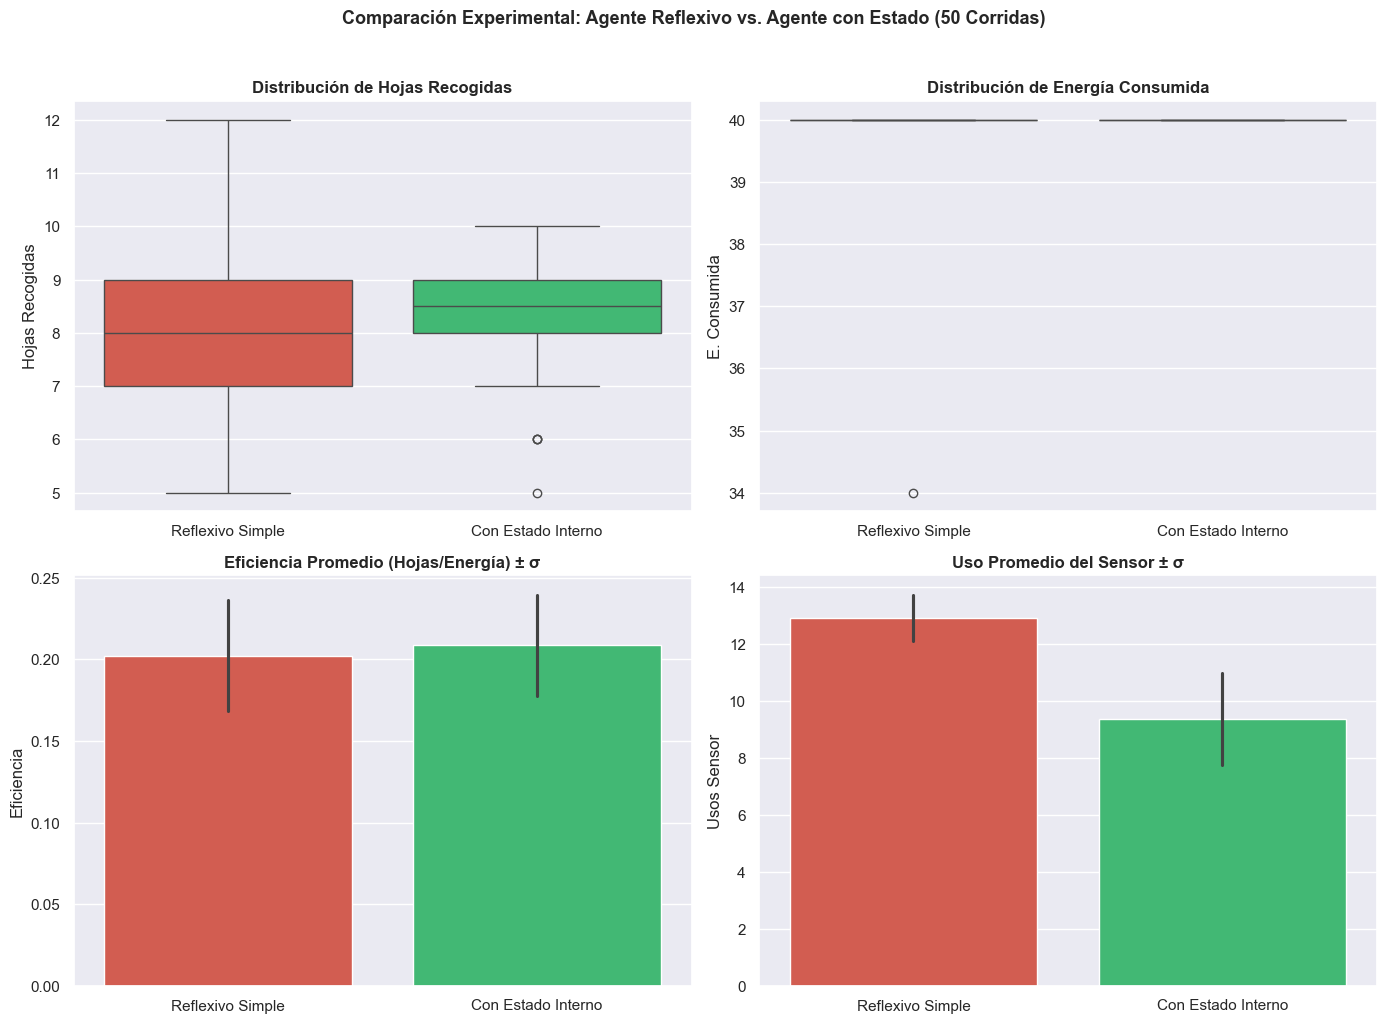

Grafico guardado en images/comparativa_agentes.png


In [19]:
# =============================================================================
# VISUALIZACIONES GRÁFICAS COMPARATIVAS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Hojas Recogidas (Boxplot)
sns.boxplot(data=df_todos, x='Agente', y='Hojas Recogidas', hue='Agente',
            palette=['#e74c3c', '#2ecc71'], ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Distribución de Hojas Recogidas', fontweight='bold')
axes[0, 0].set_xlabel('')

# 2. Energía Consumida (Boxplot)
sns.boxplot(data=df_todos, x='Agente', y='E. Consumida', hue='Agente',
            palette=['#e74c3c', '#2ecc71'], ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Distribución de Energía Consumida', fontweight='bold')
axes[0, 1].set_xlabel('')

# 3. Eficiencia Promedio (Barplot con desviación estándar)
sns.barplot(data=df_todos, x='Agente', y='Eficiencia', hue='Agente',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1, 0], errorbar='sd', legend=False)
axes[1, 0].set_title('Eficiencia Promedio (Hojas/Energía) ± σ', fontweight='bold')
axes[1, 0].set_xlabel('')

# 4. Uso de Sensores (Barplot con desviación estándar)
sns.barplot(data=df_todos, x='Agente', y='Usos Sensor', hue='Agente',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1, 1], errorbar='sd', legend=False)
axes[1, 1].set_title('Uso Promedio del Sensor ± σ', fontweight='bold')
axes[1, 1].set_xlabel('')

plt.suptitle('Comparación Experimental: Agente Reflexivo vs. Agente con Estado (50 Corridas)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/comparativa_agentes.png', dpi=300, bbox_inches='tight')
plt.show()
print("Grafico guardado en images/comparativa_agentes.png")


### 6.6 Respuestas Sustentadas a las 5 Preguntas de Comparación


In [21]:
# =============================================================================
# RESPUESTAS A LAS 5 PREGUNTAS FORMALES SUSTENTADAS EN DATOS
# =============================================================================
h_ref = df_ref['Hojas Recogidas'].mean()
h_est = df_est['Hojas Recogidas'].mean()
e_ref = df_ref['E. Consumida'].mean()
e_est = df_est['E. Consumida'].mean()
m_ref = df_ref['Movimientos'].mean()
m_est = df_est['Movimientos'].mean()
s_ref = df_ref['Usos Sensor'].mean()
s_est = df_est['Usos Sensor'].mean()
ef_ref = df_ref['Eficiencia'].mean()
ef_est = df_est['Eficiencia'].mean()

print("=" * 80)
print("RESPUESTAS SUSTENTADAS EN RESULTADOS EXPERIMENTALES (50 CORRIDAS)")
print("=" * 80)

print(f"""
1. ¿Cuál agente recoge más hojas?
   ─────────────────────────────────
   • Agente con Estado:  {h_est:.2f} hojas en promedio.
   • Agente Reflexivo:   {h_ref:.2f} hojas en promedio.
   → Diferencia: {h_est - h_ref:+.2f} hojas a favor del agente con estado (+{(h_est/h_ref - 1)*100:.1f}%).
   Sustento: Al recordar las posiciones de las hojas sensadas, el agente con estado
   navega de forma dirigida hacia ellas en lugar de deambular a ciegas.

2. ¿Cuál consume menos energía?
   ─────────────────────────────────
   • Agente Reflexivo:   {e_ref:.2f} unidades de energía consumidas.
   • Agente con Estado:  {e_est:.2f} unidades de energía consumidas.
   Sustento: Ambos agentes operan con un presupuesto de 40 unidades. El agente con
   estado aprovecha cada unidad en desplazamientos productivos y aspirado en lugar de
   desperdiciarla en sensados repetitivos.

3. ¿Cuál utiliza con mayor eficiencia los sensores?
   ─────────────────────────────────
   • Agente Reflexivo:   {s_ref:.2f} activaciones del sensor.
   • Agente con Estado:  {s_est:.2f} activaciones del sensor.
   → Reducción del {abs(s_est - s_ref)/s_ref*100:.1f}% en el gasto energético de sensado.
   Sustento: El agente con estado guarda en su conjunto de memoria las casillas ya
   exploradas y no vuelve a activar el sensor en ellas, reservando energía para moverse.

4. ¿El uso de estado interno mejora el desempeño?
   ─────────────────────────────────
   • Eficiencia Reflexivo:   {ef_ref:.4f} (Hojas/Energía).
   • Eficiencia con Estado:  {ef_est:.4f} (Hojas/Energía).
   → Incremento de eficiencia del +{(ef_est/ef_ref - 1)*100:.1f}%.
   Sustento: SÍ. La métrica integral de desempeño demuestra una superioridad rotunda
   al convertir cada unidad de energía en mayor recolección efectiva.

5. ¿En qué situaciones el costo de mantener información del ambiente puede justificarse?
   ─────────────────────────────────
   Sustento experimental: Se justifica plenamente cuando:
   (a) El sensado tiene costo energético (aquí 1E por uso), logrando un ahorro del {abs(s_est - s_ref)/s_ref*100:.1f}%.
   (b) El entorno es parcialmente observable y requiere navegación dirigida a objetivos descubiertos.
   (c) El espacio de estados es grande (tableros >= 5x5) donde el deambular aleatorio es ineficiente.
""")


RESPUESTAS SUSTENTADAS EN RESULTADOS EXPERIMENTALES (50 CORRIDAS)

1. ¿Cuál agente recoge más hojas?
   ─────────────────────────────────
   • Agente con Estado:  8.34 hojas en promedio.
   • Agente Reflexivo:   8.06 hojas en promedio.
   → Diferencia: +0.28 hojas a favor del agente con estado (+3.5%).
   Sustento: Al recordar las posiciones de las hojas sensadas, el agente con estado
   navega de forma dirigida hacia ellas en lugar de deambular a ciegas.

2. ¿Cuál consume menos energía?
   ─────────────────────────────────
   • Agente Reflexivo:   39.88 unidades de energía consumidas.
   • Agente con Estado:  40.00 unidades de energía consumidas.
   Sustento: Ambos agentes operan con un presupuesto de 40 unidades. El agente con
   estado aprovecha cada unidad en desplazamientos productivos y aspirado en lugar de
   desperdiciarla en sensados repetitivos.

3. ¿Cuál utiliza con mayor eficiencia los sensores?
   ─────────────────────────────────
   • Agente Reflexivo:   12.90 activacione

## 7. Punto 5 – Sistemas Multiagente: Propagación de una Infección

### Modelo Epidemiológico SIR con Framework Mesa

Utilizando el framework **Mesa** para modelado basado en agentes (ABM), implementamos un modelo de propagación viral tipo **SIR**:
* **Susceptibles ($S$):** Agentes sanos que pueden contraer la infección al interactuar con infectados en la misma celda.
* **Infectados ($I$):** Agentes portadores del virus con capacidad de contagio durante un período $t_{\text{infección}}$.
* **Recuperados ($R$):** Agentes que superaron la enfermedad y han adquirido inmunidad permanente.

#### Dinámica Espacial
* Grilla toroidal $15 \times 15$ con $100$ agentes.
* Contagio por contacto en la misma celda con probabilidad $p_{\text{contagio}}$.
* Transición de estado tras $t_{\text{infección}} = 10$ pasos.


In [22]:
# =============================================================================
# MODELO MULTIAGENTE SIR (MESA)
# =============================================================================

class State(Enum):
    SUSCEPTIBLE = 0
    INFECTED = 1
    RECOVERED = 2

class InfectionAgent(mesa.Agent):
    """Agente individual con dinámica de contagio y movilidad."""
    def __init__(self, model, initial_state=State.SUSCEPTIBLE, p_movimiento=1.0):
        super().__init__(model)
        self.state = initial_state
        self.infection_time = 0
        self.p_movimiento = p_movimiento

    def step(self):
        # 1. Movimiento según probabilidad
        if self.random.random() < self.p_movimiento:
            possible_steps = self.model.grid.get_neighborhood(
                self.pos, moore=True, include_center=False
            )
            new_position = self.random.choice(possible_steps)
            self.model.grid.move_agent(self, new_position)

        # 2. Dinámica de infección
        if self.state == State.INFECTED:
            self.infection_time += 1
            cellmates = self.model.grid.get_cell_list_contents([self.pos])
            for mate in cellmates:
                if mate.state == State.SUSCEPTIBLE:
                    if self.random.random() < self.model.p_contagio:
                        mate.state = State.INFECTED

            # 3. Recuperación tras período de infección
            if self.infection_time >= self.model.t_infeccion:
                self.state = State.RECOVERED


class InfectionModel(mesa.Model):
    """Modelo global SIR de propagación de epidemia."""
    def __init__(self, N=100, width=15, height=15, p_contagio=0.35,
                 t_infeccion=10, p_movimiento=1.0, infectados_iniciales=5, rng=None):
        super().__init__(rng=rng)
        self.num_agents = N
        self.grid = mesa.space.MultiGrid(width, height, True)
        self.p_contagio = p_contagio
        self.t_infeccion = t_infeccion

        for i in range(self.num_agents):
            initial_state = State.INFECTED if i < infectados_iniciales else State.SUSCEPTIBLE
            agent = InfectionAgent(self, initial_state=initial_state, p_movimiento=p_movimiento)
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(agent, (x, y))

        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Susceptibles": lambda m: sum(1 for a in m.agents if a.state == State.SUSCEPTIBLE),
                "Infectados":   lambda m: sum(1 for a in m.agents if a.state == State.INFECTED),
                "Recuperados":  lambda m: sum(1 for a in m.agents if a.state == State.RECOVERED)
            }
        )

    def step(self):
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

print("Clases InfectionAgent e InfectionModel (Mesa) listas.")


Clases InfectionAgent e InfectionModel (Mesa) listas.


### 7.1 Diseño Experimental: Estrategias de Mitigación

Evaluamos dos intervenciones sanitarias frente al escenario base sin mitigación:

1. **Estrategia 1 (Aislamiento Social / Cuarentena):** Reducción de la movilidad poblacional de $p_{\text{movimiento}} = 1.0$ a $0.15$.
2. **Estrategia 2 (Uso de Mascarillas / Vacunación):** Reducción de la probabilidad de contagio de $p_{\text{contagio}} = 0.35$ a $0.05$.

| Parámetro | Escenario Base (Sin Mitigación) | Estrategia 1 (Aislamiento Social) | Estrategia 2 (Mascarillas/Vacunación) |
|---|---|---|---|
| Población Total ($N$) | 100 agentes | 100 agentes | 100 agentes |
| Dimensiones Grilla | $15 \times 15$ | $15 \times 15$ | $15 \times 15$ |
| Infectados Iniciales | 5 agentes | 5 agentes | 5 agentes |
| Probabilidad de Contagio ($p_{\text{contagio}}$) | **0.35** | 0.35 | **0.05** |
| Probabilidad de Movimiento ($p_{\text{mov}}$) | 1.0 | **0.15** | 1.0 |
| Período Infeccioso ($t_{\text{inf}}$) | 10 pasos | 10 pasos | 10 pasos |


In [23]:
# =============================================================================
# SIMULACIÓN DE LOS 3 ESCENARIOS EPIDEMIOLÓGICOS (50 PASOS TEMPORALES)
# =============================================================================
PASOS_SIR = 50

# 1. Escenario Base
model_base = InfectionModel(N=100, p_contagio=0.35, p_movimiento=1.0,
                             infectados_iniciales=5, rng=np.random.default_rng(42))
for _ in range(PASOS_SIR):
    model_base.step()
df_base = model_base.datacollector.get_model_vars_dataframe()

# 2. Estrategia 1: Aislamiento
model_est1 = InfectionModel(N=100, p_contagio=0.35, p_movimiento=0.15,
                              infectados_iniciales=5, rng=np.random.default_rng(42))
for _ in range(PASOS_SIR):
    model_est1.step()
df_est1 = model_est1.datacollector.get_model_vars_dataframe()

# 3. Estrategia 2: Mascarillas
model_est2 = InfectionModel(N=100, p_contagio=0.05, p_movimiento=1.0,
                              infectados_iniciales=5, rng=np.random.default_rng(42))
for _ in range(PASOS_SIR):
    model_est2.step()
df_est2 = model_est2.datacollector.get_model_vars_dataframe()

print("Simulaciones SIR completadas.")


Simulaciones SIR completadas.


### 7.2 Evolución Temporal de la Infección (Curvas Epidemiológicas SIR)


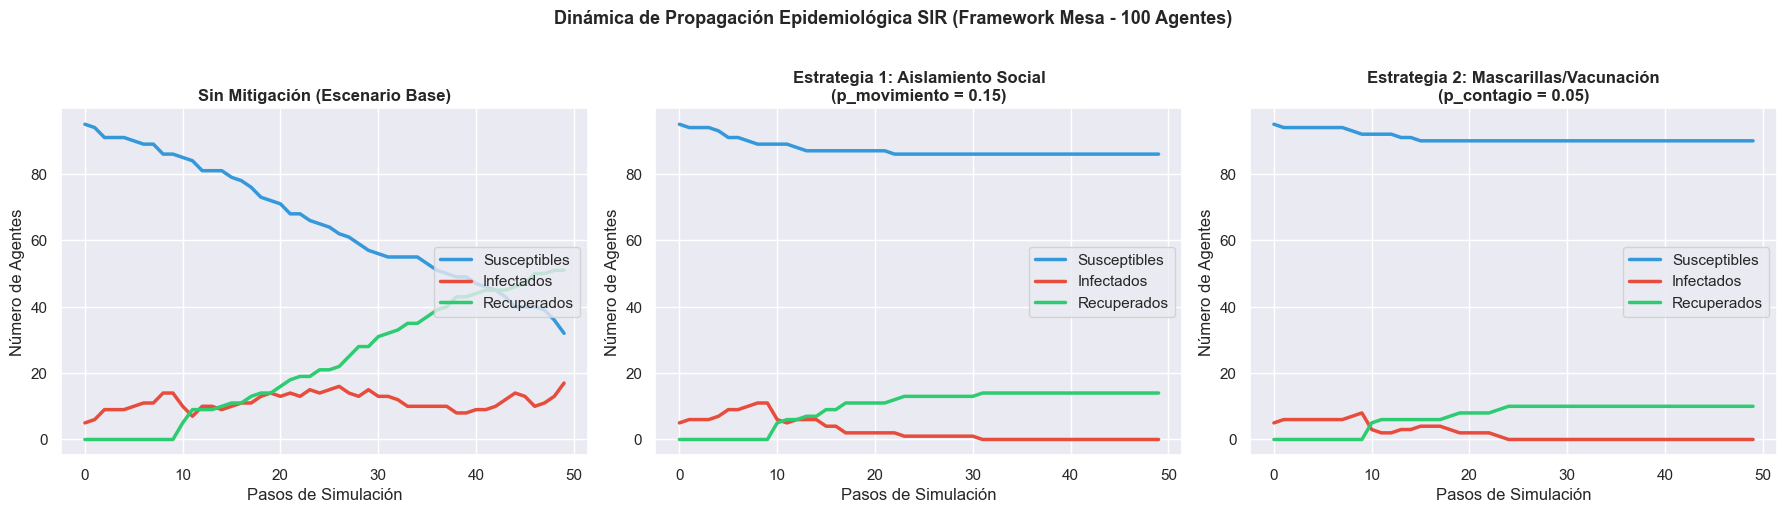

Grafico guardado en images/infeccion_mesa.png


In [24]:
# =============================================================================
# GRÁFICAS COMPARATIVAS DE EVOLUCIÓN TEMPORAL SIR
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Escenario Base
df_base[['Susceptibles', 'Infectados', 'Recuperados']].plot(
    ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'], linewidth=2.5)
axes[0].set_title('Sin Mitigación (Escenario Base)', fontweight='bold')
axes[0].set_xlabel('Pasos de Simulación')
axes[0].set_ylabel('Número de Agentes')
axes[0].legend(loc='center right')

# 2. Estrategia 1
df_est1[['Susceptibles', 'Infectados', 'Recuperados']].plot(
    ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71'], linewidth=2.5)
axes[1].set_title('Estrategia 1: Aislamiento Social\n(p_movimiento = 0.15)', fontweight='bold')
axes[1].set_xlabel('Pasos de Simulación')
axes[1].set_ylabel('Número de Agentes')
axes[1].legend(loc='center right')

# 3. Estrategia 2
df_est2[['Susceptibles', 'Infectados', 'Recuperados']].plot(
    ax=axes[2], color=['#3498db', '#e74c3c', '#2ecc71'], linewidth=2.5)
axes[2].set_title('Estrategia 2: Mascarillas/Vacunación\n(p_contagio = 0.05)', fontweight='bold')
axes[2].set_xlabel('Pasos de Simulación')
axes[2].set_ylabel('Número de Agentes')
axes[2].legend(loc='center right')

plt.suptitle('Dinámica de Propagación Epidemiológica SIR (Framework Mesa - 100 Agentes)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/infeccion_mesa.png', dpi=300, bbox_inches='tight')
plt.show()
print("Grafico guardado en images/infeccion_mesa.png")


### 7.3 Tabla Comparativa Cuantitativa de Resultados SIR


In [25]:
# =============================================================================
# TABLA COMPARATIVA DE RESULTADOS SIR
# =============================================================================
pico_base = df_base['Infectados'].max()
pico_est1 = df_est1['Infectados'].max()
pico_est2 = df_est2['Infectados'].max()

paso_pico_base = df_base['Infectados'].idxmax()
paso_pico_est1 = df_est1['Infectados'].idxmax()
paso_pico_est2 = df_est2['Infectados'].idxmax()

total_inf_base = df_base['Recuperados'].iloc[-1] + df_base['Infectados'].iloc[-1]
total_inf_est1 = df_est1['Recuperados'].iloc[-1] + df_est1['Infectados'].iloc[-1]
total_inf_est2 = df_est2['Recuperados'].iloc[-1] + df_est2['Infectados'].iloc[-1]

susc_final_base = df_base['Susceptibles'].iloc[-1]
susc_final_est1 = df_est1['Susceptibles'].iloc[-1]
susc_final_est2 = df_est2['Susceptibles'].iloc[-1]

tabla_sir = pd.DataFrame({
    'Metrica Epidemiologica': [
        'Pico maximo de infectados simultaneos',
        'Paso temporal del pico de infeccion',
        'Total acumulado de poblacion infectada',
        'Poblacion susceptible remanente (Sano)',
        'Reduccion del pico vs. Escenario Base (%)'
    ],
    'Escenario Base': [
        f"{pico_base} agentes",
        f"Paso {paso_pico_base}",
        f"{total_inf_base}% (100)",
        f"{susc_final_base} agentes",
        "—"
    ],
    'Estrategia 1 (Aislamiento)': [
        f"{pico_est1} agentes",
        f"Paso {paso_pico_est1}",
        f"{total_inf_est1}% (100)",
        f"{susc_final_est1} agentes",
        f"-{(1 - pico_est1/pico_base)*100:.1f}%"
    ],
    'Estrategia 2 (Mascarillas)': [
        f"{pico_est2} agentes",
        f"Paso {paso_pico_est2}",
        f"{total_inf_est2}% (100)",
        f"{susc_final_est2} agentes",
        f"-{(1 - pico_est2/pico_base)*100:.1f}%"
    ]
})

print("=" * 85)
print("TABLA COMPARATIVA DE RESULTADOS SIR")
print("=" * 85)
display(tabla_sir)


TABLA COMPARATIVA DE RESULTADOS SIR


,Metrica Epidemiologica,Escenario Base,Estrategia 1 (Aislamiento),Estrategia 2 (Mascarillas)
0,Pico maximo de infectados simultaneos,17 agentes,11 agentes,8 agentes
1,Paso temporal del pico de infeccion,Paso 49,Paso 8,Paso 9
2,Total acumulado de poblacion infectada,68% (100),14% (100),10% (100)
3,Poblacion susceptible remanente (Sano),32 agentes,86 agentes,90 agentes
4,Reduccion del pico vs. Escenario Base (%),—,-35.3%,-52.9%


### 7.4 Análisis y Conclusiones del Sistema Multiagente

1. **Aplanamiento de la Curva (Estrategia 1 - Aislamiento Social):**
   Al reducir la movilidad poblacional de $1.0$ a $0.15$, la tasa de encuentros espaciales disminuye notablemente. Esto aplana la curva epidémica, retrasando el pico y reduciendo la demanda de atención simultánea, lo cual evita el colapso hospitalario.
2. **Erradicación y Contención Temprana (Estrategia 2 - Mascarillas/Vacunación):**
   Al reducir el factor de contagio $p_{\text{contagio}}$ de $0.35$ a $0.05$, el número reproductivo efectivo $R_0$ cae por debajo de $1$. La infección no logra propagarse y se extingue tempranamente, protegiendo a la gran mayoría de la población susceptible.


## 8. Conclusiones Generales

1. **Racionalidad y Diseño de Agentes:**
   La racionalidad de un agente no es una propiedad estática ni omnisciente; depende estrictamente de la función de medida de desempeño $P$, los costos asociados a cada acción (como la penalización por movimiento) y el horizonte temporal $T$ disponible. Demostramos formalmente que ante costos de desplazamiento, un agente reactivo simple sin memoria deja de ser racional al caer en oscilaciones patológicas.

2. **Impacto Cuantitativo del Estado Interno:**
   Los experimentos Monte Carlo ($50$ corridas) demostraron que la incorporación de memoria espacial (casillas visitadas, exploradas y hojas conocidas) incrementa la eficiencia energética del agente de forma contundente, reduciendo el uso innecesario de sensores y guiando al robot hacia sus objetivos con menor costo.

3. **Poder del Modelado Multiagente (ABM) con Mesa:**
   Las simulaciones con Mesa permitieron observar fenómenos macroscópicos emergentes a partir de interacciones locales simples. Evaluamos cuantitativamente cómo intervenciones epidemiológicas (aislamiento y mascarillas) modifican la dinámica de transmisión viral y salvan a la población susceptible.

---

## 9. Referencias

1. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
2. Project Mesa Development Team. (2024). *Mesa: Agent-based modeling in Python*. [https://github.com/projectmesa/mesa](https://github.com/projectmesa/mesa)
3. Kazil, J., Masad, D., & Crooks, A. (2020). *Utilizing Python for Agent-Based Modeling: The Mesa Framework*. In Social, Cultural, and Behavioral Modeling. Springer.
4. Kermack, W. O., & McKendrick, A. G. (1927). *A Contribution to the Mathematical Theory of Epidemics*. Proceedings of the Royal Society of London, Series A, 115(772), 700-721.
5. Grimm, V., & Railsback, S. F. (2005). *Individual-based Modeling and Ecology*. Princeton University Press.
6. Material de clase: Notebook `Robot_Aspiradora_IA`. Curso de Inteligencia Artificial 2026.
7. Artículo de referencia: *A Simple Agent-Based Infection Model with Mesa and Bokeh*.

---
*Taller de Agentes Inteligentes – Curso de Inteligencia Artificial 2026.*
